In [28]:
import pandas as pd
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy  

country = 'DEU'
# country = 'NLD'
# country = 'GBR'

In [23]:
#Define QID - question matching -- WVS wave 7
qids = ['Q36','Q125','Q106','Q28','Q111','Q121','Q108','Q130','Q198','Q235']
name_dict = {
    "Q36":  "Gay Parenting",
    "Q125": "Refugee Asylum",
    "Q106": "Income Equality",
    "Q28":  "Maternal Employment",
    "Q111": "Environment vs Economy",
    "Q121": "Immigration Impact",
    "Q108": "Government Responsibility",
    "Q130": "Immigration Policy",
    "Q198": "Government Surveillance",
    "Q235": "Strong Leader",
}

def get_counts(path, qids): #function to get a dict with counts for each question
    value_list = []

    for id in qids:
        df = pd.read_csv(path + id + ".csv")
        df['Response'] = pd.to_numeric(df['Response'], errors='coerce') 
        value_counts = Counter(df['Response'].dropna())

        if id in ["Q36", "Q121"]:
            answers = {i: value_counts[i] for i in range(1, 6)}
        elif id in ["Q125"]:
            answers = {i: value_counts[i] for i in range(0, 3)}
        elif id in ["Q111"]:
            answers = {i: value_counts[i] for i in range(1, 4)}
        elif id in ["Q106","Q108"]:
            answers = {i: value_counts[i] for i in range(1, 11)}
        else:
            answers = {i: value_counts[i] for i in range(1, 5)} #4

        value_list.append({name_dict[id]: answers})

    return value_list


In [29]:
def get_human_counts(path, qids): #getting results from wvs 7
     anes_df = pd.read_csv(path)
     human_values = []

     for id in qids:
          human_counts = Counter(anes_df[id].dropna())
          if id in ["Q36", "Q121"]:
               answers = {i: human_counts[i] for i in range(1, 6)}
          elif id in ["Q125"]:
               answers = {i: human_counts[i] for i in range(0, 3)}
          elif id in ["Q111"]:
               answers = {i: human_counts[i] for i in range(1, 4)}
          elif id in ["Q106","Q108"]:
               answers = {i: human_counts[i] for i in range(1, 11)}
          else:
               answers = {i: human_counts[i] for i in range(1, 5)} #4
          human_values.append({name_dict[id]: answers})

     return human_values

human_results = get_human_counts(f"../data/WVS_Wave_7_{country}.csv", qids)

In [15]:
#JSD divergence is a more numerically stable version of KL-divergence - better for our case
def jsd_divergence_between_sets(set1, set2, base=2):
    jsd_results = {}

    dict1 = {list(d.keys())[0]: list(d.values())[0] for d in set1}
    dict2 = {list(d.keys())[0]: list(d.values())[0] for d in set2}

    for question in dict1.keys():
        if question not in dict2:
            continue 

        p_counts = dict1[question]
        q_counts = dict2[question]

        p = np.array([p_counts.get(k, 0) for k in p_counts], dtype=float)
        q = np.array([q_counts.get(k, 0) for k in p_counts], dtype=float)

        p /= p.sum()
        q /= q.sum()

        epsilon = 1e-10
        p = np.clip(p, epsilon, 1)
        q = np.clip(q, epsilon, 1)

        m = 0.5 * (p + q)
        jsd_pq = 0.5 * (entropy(p, m, base=base) + entropy(q, m, base=base)) 
        jsd_results[question] = jsd_pq

    return jsd_results


In [ ]:
# GPT-4.1
model_name = 'gpt4.1'
# T=0

replicate_path = f"../Publication Results/Gpt4.1-Mini-Determinstic/main_mq_wvs_results/{country}/full_results_wvs7_original_{country}_"
reformulated_path = f"../Publication Results/Gpt4.1-Mini-Determinstic/main_mq_wvs_reform_results/{country}/full_results_wvs7_reformulated_{country}_"

replicate_results = get_counts(replicate_path, qids)
reformulated_results = get_counts(reformulated_path, qids)


jsd_results_replicate = jsd_divergence_between_sets(human_results, replicate_results, base=2)
jsd_results_reformulated = jsd_divergence_between_sets(human_results, reformulated_results, base=2)

In [31]:
def shift_refugee_asylum(data):
    """Shift 'Refugee Asylum' keys from 0-indexed to 1-indexed, in place."""
    for entry in data:
        if 'Refugee Asylum' in entry:
            counts = entry['Refugee Asylum']
            entry['Refugee Asylum'] = {k + 1: v for k, v in counts.items()}
    return data

for results in (replicate_results, reformulated_results, human_results):
    shift_refugee_asylum(results)

In [ ]:
# replicate + two condition
def plot_replicate_w_two_condition_stacked(silicon_results_1, silicon_results_2, silicon_results_3, jsd_results1, jsd_results2, label1, label2, label3, output_path=''):
    categories = [
        'Environment vs Economy',    # ← Climate Change
        # Current Economy — no WVS counterpart (skipped)
        'Refugee Asylum',            # ← Refugee Allowing
        'Government Responsibility', # ← Health Insurance
        'Income Equality',           # ← Income Inequality
        'Immigration Impact',        # ← Race Diversity
        # Drug Addiction — no WVS counterpart (skipped)
        'Gay Parenting',             # ← Gay Marriage
        # Gun Regulation — no WVS counterpart (skipped)
        'Maternal Employment',       # ← Gender Role
        # WVS-only topics (no ANES analog)
        'Immigration Policy',
        'Government Surveillance',
        'Strong Leader',
    ]
    x = np.arange(len(categories))

    silicon_dict1 = {list(d.keys())[0]: list(d.values())[0] for d in silicon_results_1}
    silicon_dict2 = {list(d.keys())[0]: list(d.values())[0] for d in silicon_results_2}
    silicon_dict3 = {list(d.keys())[0]: list(d.values())[0] for d in silicon_results_3}
 
    # Define colors
    silicon_colors_1 = ['#4A90E2', '#D0021B', '#7ED321', '#F5A623', '#9013FE']
    silicon_colors_2 = ['#A4C8F0', '#F58F8F', '#B8E986', '#F8E79C', '#C9A2F7'] 

    N = 10
    silicon_base_colors = [
        tuple(c[:3]) for c in plt.get_cmap("RdBu")(np.linspace(0.08, 0.95, N))
    ]

    silicon_colors_1 = [(*rgb, 1.000) for rgb in silicon_base_colors]  # solid
    silicon_colors_3 = [(*rgb, 0.725) for rgb in silicon_base_colors]  # in between
    silicon_colors_2 = [(*rgb, 0.450) for rgb in silicon_base_colors]  # lightest
    # silicon_colors_2 = silicon_colors_1


    silicon_base_colors = [
        (0.12, 0.47, 0.71),  # blue
        (0.20, 0.63, 0.17),  # green
        (0.96, 0.73, 0.07),  # gold
        (1.00, 0.50, 0.00),  # orange
        (0.78, 0.24, 0.24),  # red
        (0.58, 0.40, 0.74),  # purple
        (0.55, 0.34, 0.29),  # brown
        (0.89, 0.47, 0.76),  # pink
        (0.50, 0.50, 0.50),  # gray
        (0.09, 0.75, 0.81),  # cyan
    ]

    silicon_colors_1 = [(*rgb, 1.000) for rgb in silicon_base_colors]  # solid
    silicon_colors_3 = [(*rgb, 0.725) for rgb in silicon_base_colors]  # in between
    silicon_colors_2 = [(*rgb, 0.450) for rgb in silicon_base_colors]  # lightest



    silicon1_stack = []
    silicon2_stack = []
    silicon3_stack = []
    silicon4_stack = []
    jsd1 = []
    jsd2 = []
    jsd3 = []
    jsd4 = []

    # --- Build stacked distributions for each category ---
    for question in categories:
        s1_dist = np.array(list(silicon_dict1[question].values()), dtype=float)
        s2_dist = np.array(list(silicon_dict2[question].values()), dtype=float)
        s3_dist = np.array(list(silicon_dict3[question].values()), dtype=float)

        s1_dist /= s1_dist.sum()
        s2_dist /= s2_dist.sum()
        s3_dist /= s3_dist.sum()

        silicon1_stack.append(s1_dist)
        silicon2_stack.append(s2_dist)
        silicon3_stack.append(s3_dist)

        jsd1.append(jsd_results1[question])
        jsd2.append(jsd_results2[question])
        # jsd3.append(jsd_results3[question])

    # fig, ax1 = plt.subplots(figsize=(6.6, 3.8))
    fig, ax1 = plt.subplots(figsize=(10, 5))
    bar_width = 0.25

    # --- Plot stacked Human bars ---
    for idx, dist in enumerate(silicon1_stack):
        bottom = 0
        for i, val in enumerate(dist):
            ax1.bar(
                x[idx] - bar_width,
                val,
                width=bar_width,
                bottom=bottom,
                color=silicon_colors_1[i],
                label=label1+'' if (idx == 0 and i == 0) else ""
            )
            bottom += val

    # --- Plot stacked Silicon bars ---
    for idx, dist in enumerate(silicon2_stack):
        bottom = 0
        for i, val in enumerate(dist):
            ax1.bar(
                x[idx] + bar_width*0,
                val,
                width=bar_width,
                bottom=bottom,
                color=silicon_colors_2[i],
                # hatch='//',                 # ★ ADD THIS ★
                # edgecolor='white',
                linewidth=0.0,
                label=label2+'' if (idx == 0 and i == 0) else ""
            )
            bottom += val

    for idx, dist in enumerate(silicon3_stack):
        bottom = 0
        for i, val in enumerate(dist):
            ax1.bar(
                x[idx] + bar_width,
                val,
                width=bar_width,
                bottom=bottom,
                color=silicon_colors_3[i],
                hatch='oo',                 # ★ ADD THIS ★
                edgecolor='white',
                linewidth=0.0,
                label=label3+'' if (idx == 0 and i == 0) else ""
            )
            bottom += val

  
    # --- Axes ---
    ax1.set_ylabel('Response rate')
    ax1.set_xticks(x)
    ax1.set_xticklabels(categories, rotation=35, ha='right')
    ax1.set_ylim(0, 1.)
    ax1.set_xmargin(0.)

    ax1.set_xlabel('')
    ax1.legend(loc='upper left', ncol=2, frameon=False, bbox_to_anchor=(0, 1.25))

    # --- JSD lines on secondary axis ---
    ax2 = ax1.twinx()
    ax2.plot(
        x+bar_width*0, jsd1,
        color='black', marker='D', markerfacecolor='none',
        markersize=9, linewidth=2, markeredgewidth=2,linestyle='-',
        label=f'JSD {label2}'
    )
    ax2.plot(
        x+bar_width, jsd2,
        color='red', marker='o', markerfacecolor='none',
        markersize=9, linewidth=2,markeredgewidth=2,
        label=f'JSD {label3}'
    ) 

    ax2.set_ylabel('JS-divergence (JSD)')
    ax2.set_ylim(0, 0.5)
    ax2.set_xmargin(0.00)

    # --- JSD legend ---
    ax2.legend(loc='upper right', frameon=False, bbox_to_anchor=(1.0, 1.25),ncol=1)
    plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})
    plt.rcParams['hatch.linewidth'] = 0.6  # previous pdf hatch linewidth

    # --- Remove figure box / spines ---
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['bottom'].set_visible(False)   # optional
    ax1.spines['left'].set_visible(False)     # optional

    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['bottom'].set_visible(False)   # optional
    ax2.spines['left'].set_visible(False)     # optional

    # ax1.yaxis.grid(True, linestyle='--', alpha=0.5)
    fig.tight_layout()

    # ----- Save figure as compact PDF -----
    if output_path != '':
        fig.savefig(
            output_path,
            format="pdf",
            bbox_inches="tight",     # removes extra margins
            pad_inches=0.05,         # small padding
            dpi=300                  # high quality
        )
        print(f"Saved figure to {output_path}")


gpt4.1
Saved figure to gpt4.1-2cond-reformulated-wvs7-GBR.pdf


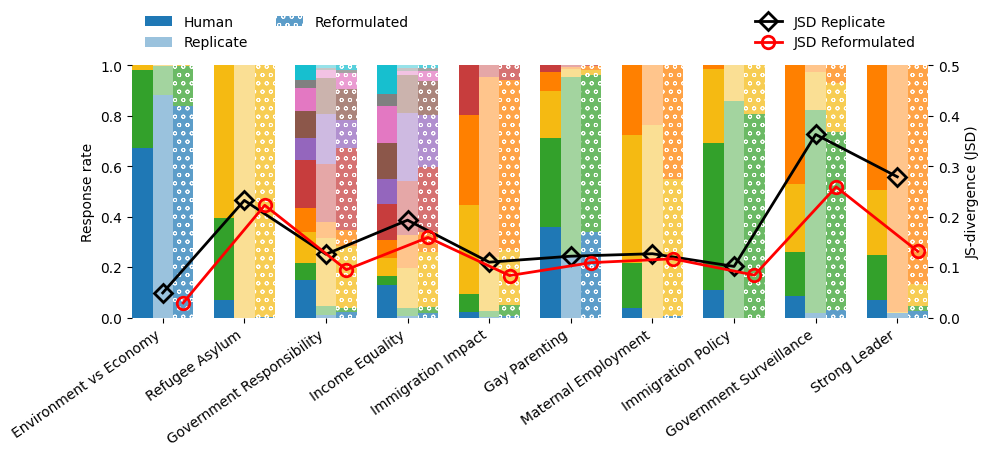

In [21]:
print(model_name)

plot_replicate_w_two_condition_stacked(human_results,replicate_results, reformulated_results, jsd_results_replicate, jsd_results_reformulated,
              'Human', 'Replicate', 'Reformulated', 'gpt4.1-2cond-reformulated-wvs7-GBR.pdf')
# llama8b-2cond-reformulated.pdf

gpt4.1
Saved figure to gpt4.1-2cond-reformulated-wvs7-NLD.pdf


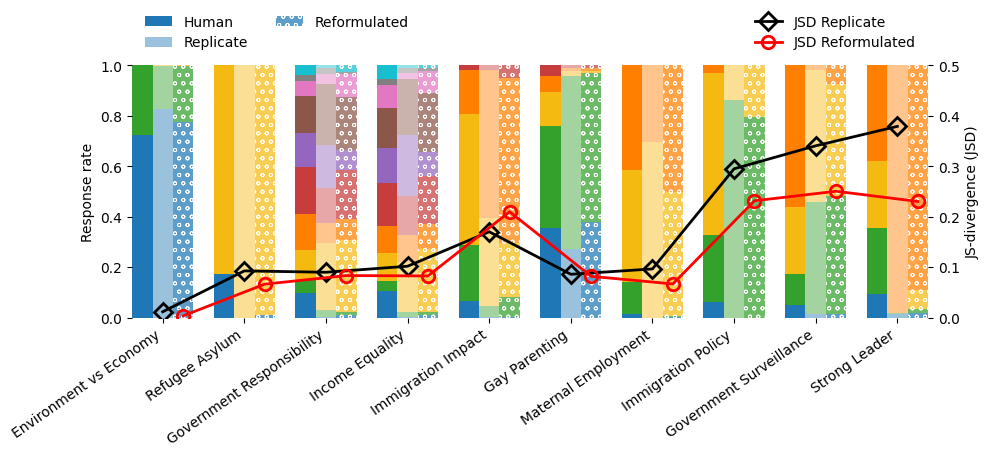

In [27]:
print(model_name)

plot_replicate_w_two_condition_stacked(human_results,replicate_results, reformulated_results, jsd_results_replicate, jsd_results_reformulated,
              'Human', 'Replicate', 'Reformulated', 'gpt4.1-2cond-reformulated-wvs7-NLD.pdf')
# llama8b-2cond-reformulated.pdf

gpt4.1
Saved figure to gpt4.1-2cond-reformulated-wvs7-DEU.pdf


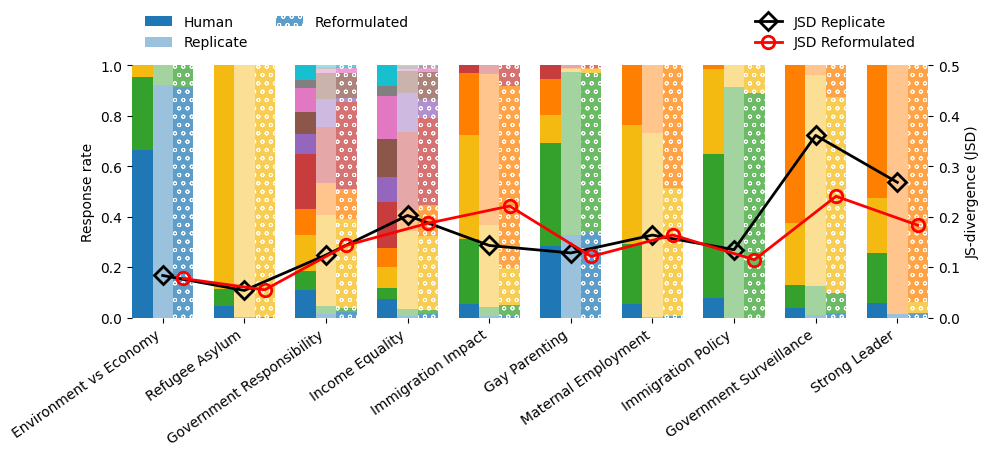

In [32]:
print(model_name)

plot_replicate_w_two_condition_stacked(human_results,replicate_results, reformulated_results, jsd_results_replicate, jsd_results_reformulated,
              'Human', 'Replicate', 'Reformulated', 'gpt4.1-2cond-reformulated-wvs7-DEU.pdf')
# llama8b-2cond-reformulated.pdf